# 0. Install Dependencies

In [1]:
# !pip install tensorflow==2.3.0
# !pip install gym
# !pip install keras
# !pip install keras-rl2

# 1. Test Random Environment with OpenAI Gym

In [1]:
import torch.nn
from gym import Env
from gym.spaces import Discrete, Box
import numpy as np
import random
import mujoco_py
import os
import math

In [2]:
class SnakeEnv(Env):
    def __init__(self):
        # Define snake model path
        self.snake_model_path = "Model/simplified-snake.xml"
        # Load snake model
        self.snake_model = mujoco_py.load_model_from_path(self.snake_model_path)
        # Load simulation engine
        self.sim = mujoco_py.MjSim(self.snake_model)
        # Visualize simulation environment
        self.viewer = mujoco_py.MjViewer(self.sim)
        # Actions we can take, left, stay, right
        self.action_space = Discrete(3)
        # Distance array
        self.observation_space = Box(low=np.array([0]), high=np.array([72]))
        # Set goal pos
        self.goal = [6, 2.5]
        # Set start distance
        self.dist = (self.goal[0] - self.sim.data.qpos[6])**2 + (self.goal[1] - self.sim.data.qpos[7])**2
        self.previous_dist = self.dist
        self.sim_length = 250000

    def step(self, action):
        # Apply action
        self.previous_dist = self.dist
        self.sim.data.ctrl[0] = (action[0]-1) * 0.01
        self.sim.data.ctrl[1] = (action[1]-1) * 0.01
        self.sim.step()
        self.dist = (self.goal[0] - self.sim.data.qpos[6])**2 + (self.goal[1] - self.sim.data.qpos[7])**2
        # Reduce simulation length by 1 step
        self.sim_length -= 1

        # Calculate reward
        if self.dist < self.previous_dist:
            reward = 1
        else:
            reward = -1

        # Check if simulation is done
        if self.sim_length <= 0 or self.dist <= 2:
            done = True
        else:
            done = False

        # Set placeholder for info
        info = {}

        # Return step information
        return self.dist, reward, done, info

    def render(self):
        self.viewer.render()

    def reset(self):
        # Reset pos
        # Load simulation engine
        self.sim = mujoco_py.MjSim(self.snake_model)
        # Visualize simulation environment
        self.viewer = mujoco_py.MjViewer(self.sim)
        self.dist = (self.goal[0] - self.sim.data.qpos[6])**2 + (self.goal[1] - self.sim.data.qpos[7])**2
        self.previous_dist = self.dist
        self.sim_length = 2500

        return self.dist

In [3]:
env = SnakeEnv()

Creating window glfw


/Users/yangzhao/opt/miniconda3/lib/python3.8/site-packages/gym/spaces/box.py:73: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(


In [5]:
env.observation_space.sample()

array([47.916103], dtype=float32)

In [5]:
env.action_space.n

3

In [4]:
episodes = 2
for episode in range(1, episodes + 1):
    dist = env.reset()
    done = False
    score = 0

    while not done:
        action1 = env.action_space.sample()
        action2 = env.action_space.sample()
        n_dist, reward, done, info = env.step([action1, action2])
        #env.render()
        score += reward
    print('Episode:{} Score:{}'.format(episode, score))

Creating window glfw
Episode:1 Score:-60
Creating window glfw
Episode:2 Score:-156


# 2. Build Neural Networks and Policy

In [7]:
import numpy as np
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.optimizers import Adam
from keras.utils.vis_utils import plot_model

In [8]:
states = env.observation_space.shape
actions = env.action_space.n
print(states, actions)

(1,) 3


In [9]:
# def build_model(states, actions):
#     model = Sequential()
#     model.add(Dense(24, activation='relu', input_shape=states))
#     model.add(Dense(24, activation='relu'))
#     model.add(Dense(actions, activation='linear'))
#     return model

In [10]:
def build_model(states, actions):
    input = Input(shape=states)
    first_layer = Dense(24, activation='relu')(input)
    second_layer = Dense(24, activation='relu')(first_layer)
    output_action1 = Dense(actions, activation='linear')(second_layer)
    output_action2 = Dense(actions, activation='linear')(second_layer)
    model = keras.Model(input, [output_action1, output_action2])
    return model

In [11]:
model = build_model(states, actions)

2022-07-13 10:49:05.161551: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


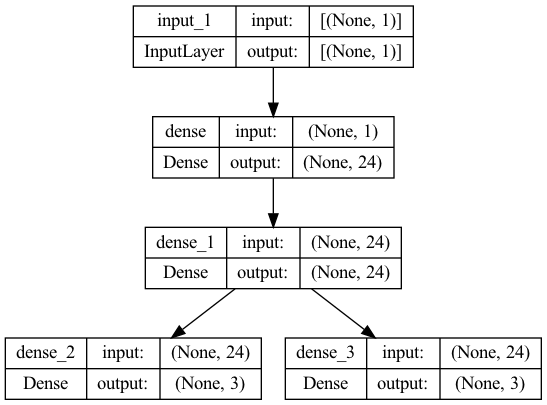

In [12]:
plot_model(model, "SnakeRL_Model.png", show_shapes=True)

In [13]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 1)]          0           []                               
                                                                                                  
 dense (Dense)                  (None, 24)           48          ['input_1[0][0]']                
                                                                                                  
 dense_1 (Dense)                (None, 24)           600         ['dense[0][0]']                  
                                                                                                  
 dense_2 (Dense)                (None, 3)            75          ['dense_1[0][0]']                
                                                                                              

In [14]:
# state_shape = env.observation_space.shape or env.observation_space.n
# action_shape = env.action_space.shape or env.action_space.n
# max_action = 2
# model_hyperparameters = {'hidden_sizes':[64, 64], 'learning_rate':1e-3}

In [15]:
# from tianshou.utils.net.common import Net
# from tianshou.utils.net.continuous import Critic, ActorProb
# import torch
# from torch.optim.lr_scheduler import LambdaLR
# from torch.distributions import Independent, Normal
# from torch.utils.tensorboard import SummaryWriter
# from tianshou.utils import TensorboardLogger
# from tianshou.exploration import GaussianNoise, OUNoise
# from tianshou.policy import PPOPolicy

In [16]:
# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# # Actor
# net_a = Net(state_shape, activation=torch.nn.Tanh, hidden_sizes=model_hyperparameters['hidden_sizes'], device=device)
# actor = ActorProb(net_a, action_shape, max_action=max_action,device=device, unbounded=True).to(device)
# # Critics
# net_c = Net(state_shape, action_shape, activation=torch.nn.Tanh, hidden_sizes=model_hyperparameters['hidden_sizes'], device=device)
# critic = Critic(net_c,device=device).to(device)

In [17]:
# torch.nn.init.constant_(actor.sigma_param, -0.5)
# for m in list(actor.modules()) + list(critic.modules()):
#     if isinstance(m, torch.nn.Linear):
#         # orthogonal initialization
#         torch.nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
#         torch.nn.init.zeros_(m.bias)
# # do last policy layer scaling, this will make initial actions have (close to)
# # 0 mean and std, and will help boost performances,
# # see https://arxiv.org/abs/2006.05990, Fig.24 for details
# for m in actor.mu.modules():
#     if isinstance(m, torch.nn.Linear):
#         torch.nn.init.zeros_(m.bias)
#         m.weight.data.copy_(0.01 * m.weight.data)
#
# optim = torch.optim.Adam(list(actor.parameters()) + list(critic.parameters()), lr=model_hyperparameters['learning_rate'])

In [18]:
# def dist(*logits):
#     return Independent(Normal(*logits), 1)

In [19]:
# # decay learning rate to 0 linearly
# max_epoch = 2
# step_per_epoch = 2500
# step_per_collect = 1024
# starting_lr = 1e-2
# ending_lr = 5e-6
# max_update_num = np.ceil(step_per_epoch / step_per_collect) * max_epoch
# lr_schedule = LambdaLR(optim, lr_lambda=lambda  epoch: starting_lr - starting_lr * (epoch / max_update_num) + ending_lr)
# policy_hyperparameters = {
#     'ent_coef': 0.01,
#     'reward_normalization': False,
#     'advantage_normalization': False,
#     'recompute_advantage': True,
#     'vf_coef': 0.25,
#     'lr_scheduler': lr_schedule,
#     'action_bound_method': 'clip',
#     'dual_clip': None,
#     'value_clip': False,
#     'max_grad_norm': 0.6
# }
# policy = PPOPolicy(actor, critic, optim, dist, **policy_hyperparameters, action_space=env.action_space)

In [20]:
# # Collectors
# use_prioritised_replay_buffer = False
# prioritized_buffer_hyperparameters = {'total_size': 2048, 'buffer_num': 1, 'alpha': 0.4, 'beta': 0.5}
# if use

# 3. Build Agent with Keras-RL

In [21]:
from rl.agents import DQNAgent
from rl.policy import BoltzmannQPolicy
from rl.memory import SequentialMemory

In [22]:
def build_agent(model, actions):
    policy = BoltzmannQPolicy()
    memory = SequentialMemory(limit=50000, window_length=1)
    dqn = DQNAgent(model=model, memory=memory, policy=policy,
                  nb_actions=actions, nb_steps_warmup=10, target_model_update=1e-2)
    return dqn

In [23]:
actions

3

In [24]:
dqn = build_agent(model, actions)
dqn.compile(Adam(lr=1e-3), metrics=['mae'])
dqn.fit(env, nb_steps=50000, visualize=False, verbose=1)

AttributeError: 'list' object has no attribute 'shape'